# 202 — Probability-weighted T uncertainty cost

This notebook treats transmissivity (`T`) as **uncertain** instead of simply testing one known error such as `T +10%` or `T -10%`.

The notebook samples a discrete probability distribution of possible `T` values around the baseline value, re-evaluates the same fixed baseline Pareto-front pumping designs for each sampled `T`, and calculates probability-weighted cost metrics.

The main project metric is **probability-weighted streamflow shortfall**, which only counts cases where uncertain `T` gives lower streamflow than the baseline-T prediction.


---
## 1. Imports, helper reload, and user controls

This first section does two important things:

1. It imports the shared helper script using a **forced reload** pattern. This avoids the cached-helper problem where Jupyter keeps using an older copy of `uncertainty_project_helpers.py` even after the file has been replaced.
2. It defines the user-editable settings for the probability model and cache behavior.

For normal project runs, keep `RERUN_REEVALUATION = False` after you have a good cache. Set it to `True` only when you need to regenerate the PyCap re-evaluations.


In [1]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Force Python/Jupyter to import the helper script from THIS notebook folder.
# -----------------------------------------------------------------------------
NOTEBOOK_DIR = Path.cwd().resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

sys.modules.pop("uncertainty_project_helpers", None)
importlib.invalidate_caches()

import uncertainty_project_helpers as up

# Confirm that the expected helper file is being used.
print("Imported helper from:", Path(up.__file__).resolve())
print("Helper version:", getattr(up, "HELPER_VERSION", "not reported"))

# Apply the shared plotting defaults. Edit up.PLOT_STYLE in the helper if you
# want project-wide figure changes, or override specific settings below.
up.apply_plot_style()

# =============================================================================
# User-editable settings
# =============================================================================
RUN_NAME = "fish_dollars_baseline_0.0_1.0_0.01"

# Use None for the full final-generation Pareto front.
# Use a small number like 5 or 10 for a quick smoke test. Default = None
N_TEST_MEMBERS = None

# Cache control:
# False = load cached re-evaluations when available; much faster.
# True  = rerun the PyCap re-evaluations; needed if you changed the probability model.
RERUN_REEVALUATION = False

HISTORIC_STREAMFLOW_CFS = 8.6
DEPLETION_OBS_NAME = "lpr:total_combined:bdpl"
PUMPING_COLUMN_FOR_HYDRO_PLOTS = "effective_total_pumping_cfs"

# =============================================================================
# Probability model for T uncertainty
# =============================================================================
# T_SIGMA_FRACTION is the standard deviation of T, expressed as a fraction of the
# baseline T. Example: 0.10 means one standard deviation equals +/-10% of T.
T_SIGMA_FRACTION = 0.10

# N_T_VALUES is the number of discrete T values sampled across the range.
# Runtime scales approximately with: n_members * N_T_VALUES.
# For 174 members and 11 T values, this is 1,914 forward calculations.
N_T_VALUES = 11

# N_SIGMA_EACH_SIDE controls the range sampled around baseline T.
# With T_SIGMA_FRACTION=0.10 and N_SIGMA_EACH_SIDE=2.0,
# the sampled T factors run from 0.8 to 1.2.
N_SIGMA_EACH_SIDE = 2.0

# Optional risk threshold.
# Leave as None unless you want to calculate the probability that each design
# falls below a specific streamflow threshold.
STREAMFLOW_THRESHOLD_CFS = None

# =============================================================================
# Project paths and output/cache files
# =============================================================================
PROJECT_DIR = up.find_lpr_pycap_opt_dir(NOTEBOOK_DIR)
dirs = up.make_project_dirs(NOTEBOOK_DIR, "202", "probability_weighted_T_uncertainty_cost")
OUTPUT_DIR = dirs["output_dir"]
CACHE_DIR = dirs["cache_dir"]
CACHE_FILE = CACHE_DIR / "202_T_probability_reevaluation_long.csv"
ERROR_CACHE_FILE = CACHE_DIR / "202_T_probability_reevaluation_errors.csv"

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CACHE_FILE:", CACHE_FILE)


Imported helper from: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/uncertainty_project_helpers.py
Helper version: 2026-05-19_202_203_normal_distribution_plot_fix
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/202_probability_weighted_T_uncertainty_cost
CACHE_FILE: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/cached_reevaluations/202_T_probability_reevaluation_long.csv


---
## 2. Build the T probability table and load the baseline design set

This section loads the original fish-dollars model context, selects the final feasible baseline Pareto-front members, and builds the discrete probability table for `T`.

The probability settings mean:

- `T_SIGMA_FRACTION = 0.10`: one standard deviation is 10% of baseline `T`.
- `N_SIGMA_EACH_SIDE = 2.0`: sample from two standard deviations below to two above baseline `T`.
- Together, those settings create a range from **0.8T to 1.2T**.
- `N_T_VALUES = 11`: evaluate 11 discrete `T` values across that range.

The row closest to `T_factor = 1.0` is renamed `baseline_T` so the later calculations know which scenario is the baseline prediction.


In [2]:
# =============================================================================
# Load source-of-truth model context and design set
# =============================================================================
# context contains the original PyCap fish-dollars forward model script, the
# baseline input dictionary, the baseline T value, and model support files.
context = up.load_fish_dollars_context(RUN_NAME, PROJECT_DIR)

# Read the original PEST++ MOU Pareto archive and select the final feasible front.
pareto_archive = up.read_pareto_archive_summary(RUN_NAME, context.run_dir)
pareto_final = up.select_final_feasible_front1(pareto_archive, n_test_members=N_TEST_MEMBERS)

# Load decision-variable populations so we can recover the pumping design for
# each Pareto member.
dv_df = up.load_decision_variable_population(context.run_dir)
q_cols = up.get_q_columns(dv_df)

# Build the probability table for uncertain T.
T_probability_table = up.make_discrete_normal_T_table(
    base_T=context.base_T,
    sigma_fraction=T_SIGMA_FRACTION,
    n_values=N_T_VALUES,
    n_sigma_each_side=N_SIGMA_EACH_SIDE,
)

# Label the sampled T value closest to baseline T as baseline_T.
# This makes baseline-relative error/shortfall calculations unambiguous.
closest_idx = (T_probability_table["T_factor"] - 1.0).abs().idxmin()
T_probability_table.loc[closest_idx, "scenario"] = "baseline_T"

# Convert the probability table into the scenario dictionary expected by the
# re-evaluation helper.
T_SCENARIOS = {
    row["scenario"]: {
        "T_factor": row["T_factor"],
        "T_value": row["T_value"],
        "probability_weight": row["probability_weight"],
    }
    for _, row in T_probability_table.iterrows()
}

print("Final feasible front-1 members:", len(pareto_final))
print("Baseline T:", context.base_T)
print("Sampled T-factor range:", T_probability_table["T_factor"].min(), "to", T_probability_table["T_factor"].max())
print("Total forward calculations if rerun:", len(pareto_final) * len(T_probability_table))
display(T_probability_table)


Final feasible front-1 members: 174
Baseline T: 1700.0
Sampled T-factor range: 0.8 to 1.2
Total forward calculations if rerun: 1914


,scenario,T_factor,T_value,z_score,probability_weight
0,T_factor_0.800,0.80,1360.0,-2.0,0.022191
1,T_factor_0.840,0.84,1428.0,-1.6,0.045589
2,T_factor_0.880,0.88,1496.0,-1.2,0.079811
3,T_factor_0.920,0.92,1564.0,-0.8,0.119065
4,T_factor_0.960,0.96,1632.0,-0.4,0.151361
5,baseline_T,1.00,1700.0,0.0,0.163967
6,T_factor_1.040,1.04,1768.0,0.4,0.151361
7,T_factor_1.080,1.08,1836.0,0.8,0.119065
8,T_factor_1.120,1.12,1904.0,1.2,0.079811
9,T_factor_1.160,1.16,1972.0,1.6,0.045589


---
## 3. Re-evaluate the designs, or load cached re-evaluations

This is the expensive section. It either:

- loads the cached long-format re-evaluation table, or
- re-runs the original fish-dollars PyCap forward model for every Pareto member and every sampled `T` value.

Use the cache whenever possible. Re-run only when the probability model or the selected members changed.


In [3]:
# =============================================================================
# Re-evaluate T probability scenarios, or load cached results
# =============================================================================
if CACHE_FILE.exists() and not RERUN_REEVALUATION:
    print("Loading cached probability-weighted re-evaluation:", CACHE_FILE)
    results_long = pd.read_csv(CACHE_FILE)
    error_df = pd.read_csv(ERROR_CACHE_FILE) if ERROR_CACHE_FILE.exists() else pd.DataFrame()
else:
    print("Running PyCap re-evaluations. This can take a while...")
    results_long, error_df = up.reevaluate_designs(
        pareto_final=pareto_final,
        dv_df=dv_df,
        q_cols=q_cols,
        context=context,
        scenarios=T_SCENARIOS,
        historic_streamflow_cfs=HISTORIC_STREAMFLOW_CFS,
        depletion_obs_name=DEPLETION_OBS_NAME,
    )
    results_long.to_csv(CACHE_FILE, index=False)
    if not error_df.empty:
        error_df.to_csv(ERROR_CACHE_FILE, index=False)
    print("Saved cache:", CACHE_FILE)

# If a cache was created by an older notebook/helper version, make sure the
# probability weights are present and current. This avoids rerunning PyCap just
# because a bookkeeping column is missing or stale.
results_long = results_long.drop(columns=["probability_weight"], errors="ignore").merge(
    T_probability_table[["scenario", "probability_weight"]],
    on="scenario",
    how="left",
)

# Basic sanity checks before summarizing.
if error_df is not None and not error_df.empty:
    print("Warning: re-evaluation errors were recorded. Displaying the first few rows:")
    display(error_df.head())

missing_weights = results_long["probability_weight"].isna().sum()
if missing_weights:
    raise ValueError(
        f"{missing_weights} rows are missing probability weights. "
        "Check that cached scenario labels match T_probability_table."
    )

print("Re-evaluation rows:", len(results_long))
print("Unique members:", results_long["member"].nunique())
print("Unique T scenarios:", results_long["scenario"].nunique())


Running PyCap re-evaluations. This can take a while...

Scenario: T_factor_0.800 | T factor: 0.8 | T value: 1360
  Re-evaluating 1 of 1914: scenario=T_factor_0.800, member=gen=47_member=5907_pso
  Re-evaluating 50 of 1914: scenario=T_factor_0.800, member=gen=41_member=5214_pso
  Re-evaluating 100 of 1914: scenario=T_factor_0.800, member=gen=47_member=5999_pso
  Re-evaluating 150 of 1914: scenario=T_factor_0.800, member=gen=34_member=4241_pso

Scenario: T_factor_0.840 | T factor: 0.84 | T value: 1428
  Re-evaluating 200 of 1914: scenario=T_factor_0.840, member=gen=38_member=4778_pso
  Re-evaluating 250 of 1914: scenario=T_factor_0.840, member=gen=24_member=2976_pso
  Re-evaluating 300 of 1914: scenario=T_factor_0.840, member=gen=33_member=4206_pso

Scenario: T_factor_0.880 | T factor: 0.88 | T value: 1496
  Re-evaluating 350 of 1914: scenario=T_factor_0.880, member=56
  Re-evaluating 400 of 1914: scenario=T_factor_0.880, member=gen=45_member=5714_pso
  Re-evaluating 450 of 1914: scenari

---
## 4. Calculate probability-weighted uncertainty metrics

This section converts the long table of re-evaluations into three summary tables:

1. `member_summary`: one row per Pareto member/design.
2. `scenario_summary`: one row per sampled `T` value.
3. `overall_summary`: project-level summary metrics.

The most important columns are:

- `probability_weighted_absolute_streamflow_error_cfs`: expected magnitude of streamflow error.
- `probability_weighted_streamflow_shortfall_cfs`: expected one-sided streamflow loss relative to baseline-T prediction.
- `streamflow_std_cfs`: spread of streamflow caused by T uncertainty.


In [4]:
# =============================================================================
# Add probability-weighted summary metrics
# =============================================================================
# The summary helper adds baseline-relative columns internally when needed.
# Do NOT call up.add_known_T_error_metrics() here; doing so can duplicate
# baseline columns if this cell is rerun during troubleshooting.

# Clean out any baseline/error columns left over from a previous partial run in
# this active notebook session. This is extra protection when rerunning cells.
metric_cols_to_drop = [
    c for c in results_long.columns
    if c.startswith("baseline_T_")
    or c.endswith("_from_baseline_cfs")
    or c in [
        "streamflow_error_cfs",
        "absolute_streamflow_error_cfs",
        "streamflow_shortfall_below_baseline_cfs",
    ]
    or c.endswith("_x")
    or c.endswith("_y")
]

results_for_summary = results_long.drop(columns=metric_cols_to_drop, errors="ignore").copy()

# Summarize probability-weighted metrics.
member_summary, scenario_summary, overall_summary = up.summarize_probability_weighted_members(
    results_for_summary,
    streamflow_threshold_cfs=STREAMFLOW_THRESHOLD_CFS,
)

print("Overall probability-weighted summary:")
display(overall_summary)

print("Scenario-level summary:")
display(scenario_summary)

print("First few member-level results:")
display(member_summary.head())


Overall probability-weighted summary:


,metric,value
0,n_members,174.000000
1,mean_probability_weighted_absolute_streamflow_error_cfs,0.114961
2,max_probability_weighted_absolute_streamflow_error_cfs,0.180857
3,mean_probability_weighted_streamflow_shortfall_cfs,0.055357
4,max_probability_weighted_streamflow_shortfall_cfs,0.086574
5,mean_streamflow_std_cfs,0.143166
6,max_streamflow_std_cfs,0.225284
7,mean_probability_streamflow_lower_than_baseline,0.418016
8,mean_probability_streamflow_below_threshold,NaN


Scenario-level summary:


,scenario,T_factor,T_value,probability_weight,n_members,mean_streamflow_cfs,mean_depletion_cfs,mean_streamflow_change_from_baseline_cfs,mean_streamflow_shortfall_below_baseline_cfs,max_streamflow_shortfall_below_baseline_cfs
0,T_factor_0.800,0.80,1360.0,0.022191,174,6.227654,2.372346,0.333157,0.000000,0.000000
1,T_factor_0.840,0.84,1428.0,0.045589,174,6.157140,2.442860,0.262644,0.000000,0.000000
2,T_factor_0.880,0.88,1496.0,0.079811,174,6.088692,2.511308,0.194196,0.000000,0.000000
3,T_factor_0.920,0.92,1564.0,0.119065,174,6.022185,2.577815,0.127689,0.000000,0.000000
4,T_factor_0.960,0.96,1632.0,0.151361,174,5.957493,2.642507,0.062996,0.000000,0.000000
5,baseline_T,1.00,1700.0,0.163967,174,5.894497,2.705503,0.000000,0.000000,0.000000
6,T_factor_1.040,1.04,1768.0,0.151361,174,5.833127,2.766873,-0.061370,0.061370,0.096333
7,T_factor_1.080,1.08,1836.0,0.119065,174,5.773249,2.826751,-0.121247,0.121247,0.189881
8,T_factor_1.120,1.12,1904.0,0.079811,174,5.714791,2.885209,-0.179706,0.179706,0.281050
9,T_factor_1.160,1.16,1972.0,0.045589,174,5.657693,2.942307,-0.236803,0.236803,0.369450


First few member-level results:


,member,generation,raw_total_pumping_cfs,effective_total_pumping_cfs,baseline_T_streamflow_cfs,baseline_T_depletion_cfs,expected_streamflow_cfs,expected_depletion_cfs,expected_streamflow_bias_from_baseline_cfs,expected_depletion_bias_from_baseline_cfs,...,depletion_p05_cfs,depletion_p50_cfs,depletion_p95_cfs,probability_weighted_absolute_streamflow_error_cfs,probability_weighted_streamflow_shortfall_cfs,probability_weighted_signed_streamflow_error_cfs,max_absolute_streamflow_error_cfs,max_streamflow_shortfall_below_baseline_cfs,probability_streamflow_lower_than_baseline,probability_streamflow_below_threshold
0,gen=47_member=5907_pso,50.0,94.529471,92.989031,7.175175,1.424825,7.177078,1.422922,0.001902,-0.001902,...,1.260058,1.406757,1.542199,0.066115,0.032106,-0.001902,0.188857,0.170882,0.418016,NaN
1,56,50.0,117.275577,117.275577,3.802680,4.797320,3.810298,4.789702,0.007618,-0.007618,...,4.339373,4.747877,5.111523,0.180017,0.086199,-0.007618,0.526297,0.453765,0.418016,NaN
2,64,50.0,116.394202,116.394202,4.142735,4.457265,4.149966,4.450034,0.007231,-0.007231,...,4.019965,4.410030,4.757533,0.171980,0.082374,-0.007231,0.502537,0.433732,0.418016,NaN
3,gen=40_member=5105_pso,50.0,115.563915,114.619359,4.318902,4.281098,4.325578,4.274422,0.006676,-0.006676,...,3.871781,4.236857,4.562695,0.161107,0.077216,-0.006676,0.470477,0.406935,0.418016,NaN
4,30,50.0,116.273157,116.273157,3.909338,4.690662,3.916910,4.683090,0.007572,-0.007572,...,4.243798,4.642584,4.996132,0.175330,0.083879,-0.007572,0.513838,0.441257,0.418016,NaN


---
## 5. Create probability-weighted uncertainty figures

This section creates the figures that explain both parts of the probability-weighted analysis:

1. **The probability model for transmissivity (`T`)**  
   These figures show the discrete `T` values used in the PyCap re-evaluations and the normal distribution that gives each value its probability weight.

2. **The hydrologic consequence of uncertain `T`**  
   These figures show how uncertainty in `T` changes predicted streamflow for the same fixed baseline Pareto-front pumping designs.

3. **The cost/risk metrics**  
   The absolute-error plot shows the expected magnitude of streamflow error. The shortfall plot shows the one-sided management risk: cases where uncertain `T` gives lower streamflow than the baseline-`T` prediction.

The two distribution figures are mostly for communication and interpretation. The actual calculations use the discrete probability table, not the smooth bell curve. The smooth line is added so it is easier to see how the discrete weights relate to the assumed normal distribution.


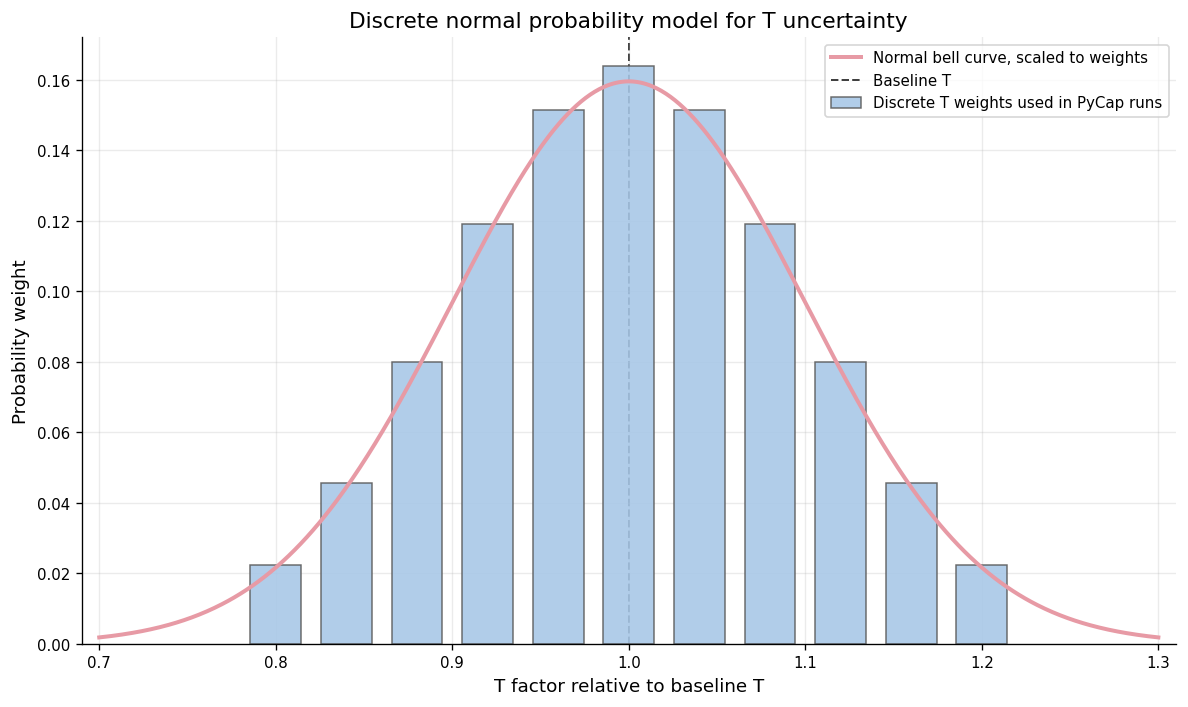

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/202_probability_weighted_T_uncertainty_cost/202_T_probability_weights_with_bell_curve.png


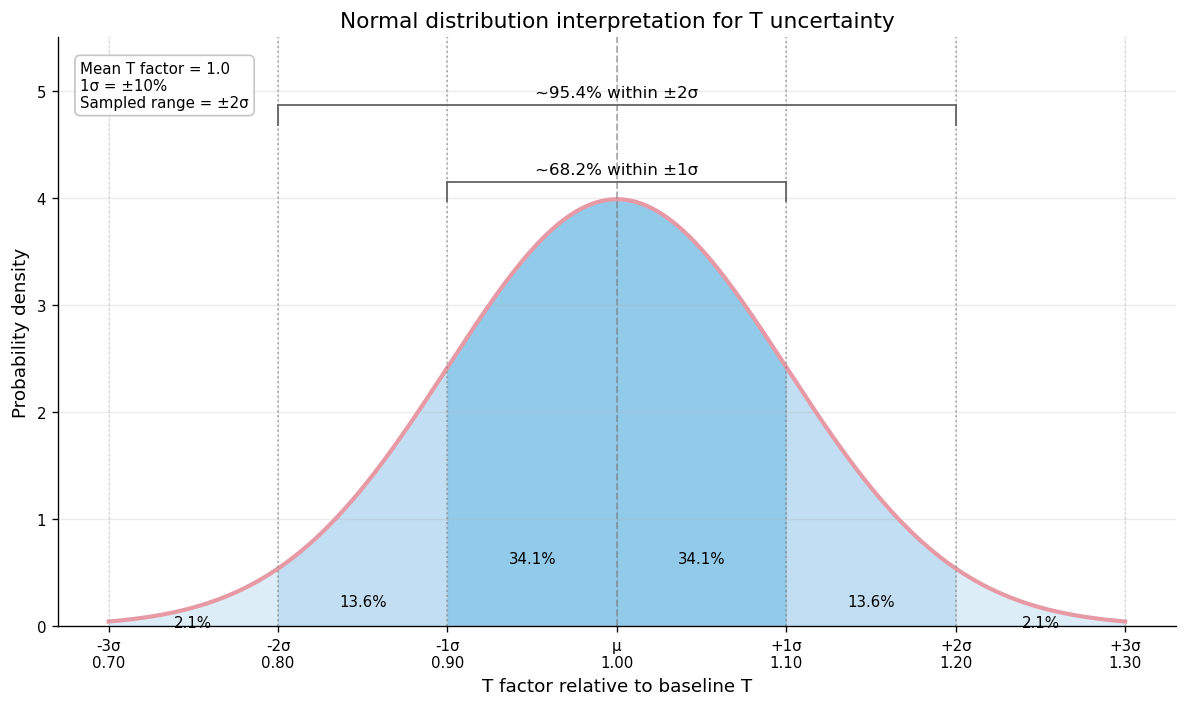

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/202_probability_weighted_T_uncertainty_cost/202_T_probability_shaded_sigma_regions.png


/workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/uncertainty_project_helpers.py:924: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


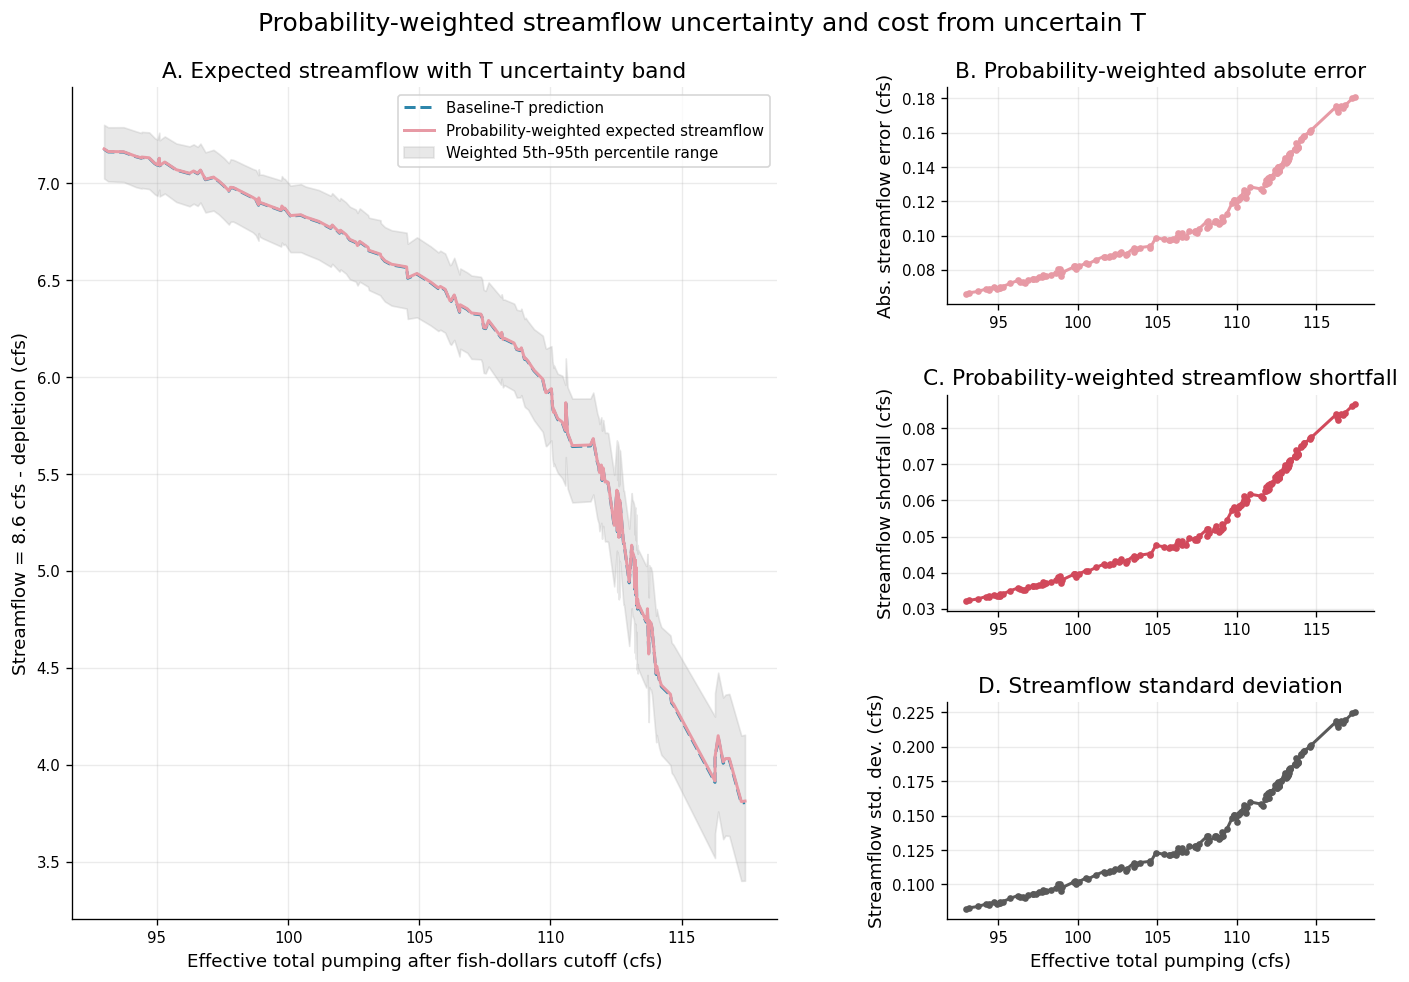

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/202_probability_weighted_T_uncertainty_cost/202_combined_streamflow_uncertainty_and_cost.png


In [5]:
# =============================================================================
# Figure 1: Discrete T probability weights with a bell-curve overlay
# =============================================================================
# This is the probability model that drives the whole notebook.
#
# The bars are the ACTUAL probability weights used in the calculations. Each bar
# corresponds to one sampled T value and one batch of PyCap re-evaluations.
#
# The smooth bell curve is only a visual guide. It shows the continuous normal
# distribution that the discrete weights approximate. For display, the curve is
# scaled onto the same y-axis as the bars so the shapes can be compared.
up.plot_T_probability_weights_with_curve(
    T_probability_table=T_probability_table,
    sigma_fraction=T_SIGMA_FRACTION,
    outfile=OUTPUT_DIR / "202_T_probability_weights_with_bell_curve.png",
    title="Discrete normal probability model for T uncertainty",
)

# =============================================================================
# Figure 2: Shaded normal-distribution teaching figure
# =============================================================================
# This plot is meant to make the probability model easier to explain in a report.
# It shows what +/-1 sigma and +/-2 sigma mean in terms of T factor.
#
# With the recommended settings:
#   T_SIGMA_FRACTION = 0.10
#   N_SIGMA_EACH_SIDE = 2.0
# the sampled range is 0.8T to 1.2T.
up.plot_T_probability_shaded_sigma_regions(
    sigma_fraction=T_SIGMA_FRACTION,
    n_sigma_each_side=N_SIGMA_EACH_SIDE,
    outfile=OUTPUT_DIR / "202_T_probability_shaded_sigma_regions.png",
    title="Normal distribution interpretation for T uncertainty",
)

# Sort once so all hydrologic plots draw in a consistent left-to-right order.
# The x-axis is effective total pumping because the fish-dollars forward model
# can shut off farms when pumping drops below the 70% rule.
plot_df = up.sort_for_plot(member_summary, PUMPING_COLUMN_FOR_HYDRO_PLOTS)

# NOTE: See the 210_archived code for single plot code that goes here

# =============================================================================
# Figure 7: Combined report figure
# =============================================================================
# This combines the three most important outcome plots into one figure:
#   - left side: expected streamflow with uncertainty band,
#   - upper right: probability-weighted absolute streamflow error,
#   - lower right: probability-weighted streamflow shortfall.
#
# The left panel spans both rows so the main hydrologic result gets the most room.
up.plot_probability_weighted_streamflow_dashboard(
    member_summary=member_summary,
    xcol=PUMPING_COLUMN_FOR_HYDRO_PLOTS,
    outfile=OUTPUT_DIR / "202_combined_streamflow_uncertainty_and_cost.png",
    title="Probability-weighted streamflow uncertainty and cost from uncertain T",
)


---
## 6. Save final outputs

This final section writes the main tables to the notebook output folder. These files are used by Notebook 203 for report figures and project summaries.


In [6]:
# =============================================================================
# Save outputs
# =============================================================================
results_long.to_csv(OUTPUT_DIR / "202_T_probability_reevaluation_long.csv", index=False)
member_summary.to_csv(OUTPUT_DIR / "202_probability_weighted_member_summary.csv", index=False)
scenario_summary.to_csv(OUTPUT_DIR / "202_T_probability_scenario_summary.csv", index=False)
T_probability_table.to_csv(OUTPUT_DIR / "202_T_probability_weights.csv", index=False)
overall_summary.to_csv(OUTPUT_DIR / "202_probability_weighted_overall_summary.csv", index=False)
if error_df is not None and not error_df.empty:
    error_df.to_csv(OUTPUT_DIR / "202_T_probability_reevaluation_errors.csv", index=False)

print("Saved files:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(" -", f.name)


Saved files:
 - 202_T_probability_reevaluation_long.csv
 - 202_T_probability_scenario_summary.csv
 - 202_T_probability_shaded_sigma_regions.png
 - 202_T_probability_weights.csv
 - 202_T_probability_weights_with_bell_curve.png
 - 202_combined_streamflow_uncertainty_and_cost.png
 - 202_probability_weighted_member_summary.csv
 - 202_probability_weighted_overall_summary.csv
